In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [6]:

def golden_section_search(x0, y0, f, a, b, tolerance=1e-7):    
	phi = (1 + math.sqrt(5)) / 2
	resphi = 2 - phi
	x1 = a + resphi * (b - a)
	x2 = b - resphi * (b - a)
 
	def dist_sq(x): 
		return (x - x0)**2 + (f(x) - y0)**2
 
	f_x1 = dist_sq(x1)
	f_x2 = dist_sq(x2)
 
	iterations = []
 
	while abs(b - a) > tolerance:
		iterations.append((a, b))
     
		if f_x1 < f_x2:
			b = x2
			x2 = x1
			f_x2 = f_x1
			x1 = a + resphi * (b - a)
			f_x1 = dist_sq(x1)
		else:
			a = x1
			x1 = x2
			f_x1 = f_x2
			x2 = b - resphi * (b - a)
			f_x2 = dist_sq(x2)
   
	best_x = (a + b) / 2

	return math.sqrt(dist_sq(best_x)), best_x, iterations


In [8]:
x0 = -8
y0 = 0

f = lambda x : x**2 + 5

a = -5
b = 5

shortest_distance, closest_x, iterations = golden_section_search(x0, y0, f, a, b)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [(-5, 5), (-5, 1.180339887498949), (-2.6393202250021033, 1.180339887498949), (-1.180339887498949, 1.180339887498949), (-1.180339887498949, 0.27864045000420634), (-1.180339887498949, -0.2786404500042057), (-0.8359213500126185, -0.2786404500042057), (-0.8359213500126185, -0.4915028125262878), (-0.8359213500126185, -0.6230589874905367), (-0.754615162454785, -0.6230589874905367), (-0.7043651750483699, -0.6230589874905367), (-0.7043651750483699, -0.6541151876419552), (-0.6851713877933737, -0.6541151876419552), (-0.6851713877933737, -0.6659776005383774), (-0.6778400134347997, -0.6659776005383774), (-0.6778400134347997, -0.6705086390762256), (-0.6750396776140739, -0.6705086390762256), (-0.6733089748969515, -0.6705086390762256), (-0.6733089748969515, -0.671578272179829), (-0.6726479052834325, -0.671578272179829), (-0.672239341793348, -0.671578272179829), (-0.672239341793348, -0.6718307783032635), (-0.672239341793348, -0.6719868356699136), (-0.6721428930365635, -0.6719868356699136),

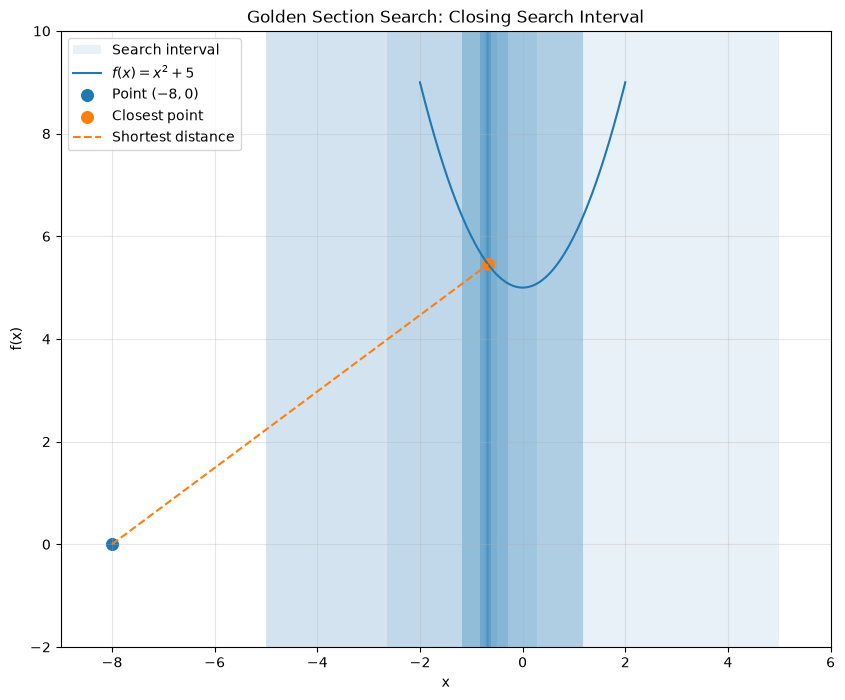

In [21]:
closest_y = f(closest_x)

x_values = np.linspace(-2, 2, 500)

plt.figure(figsize=(10, 8))

# Show the shrinking intervals
for i, (a, b) in enumerate(iterations):
    plt.axvspan(
        a, b,
        alpha=0.10,
        label="Search interval" if i == 0 else None
    )

# Plot parabola
plt.plot(x_values, f(x_values), label=r"$f(x)=x^2+5$")

# Original point
plt.scatter(x0, y0, s=70, label="Point $(-8,0)$")

# Closest point
plt.scatter(
    closest_x,
    closest_y,
    s=70,
    label="Closest point"
)

# Line showing shortest distance
plt.plot(
    [x0, closest_x],
    [y0, closest_y],
    "--",
    label="Shortest distance"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Golden Section Search: Closing Search Interval")

plt.xlim(-9, 6)
plt.ylim(-2, 10)

plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    "media/golden.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
x0 = -1
y0 = 5

f = lambda x : x**2 + 5

a = -5
b = 5

shortest_distance, closest_x, iterations = golden_section_search(x0, y0, f, a, b)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [(-5, 5), (-5, 1.180339887498949), (-2.6393202250021033, 1.180339887498949), (-1.180339887498949, 1.180339887498949), (-1.180339887498949, 0.27864045000420634), (-1.180339887498949, -0.2786404500042057), (-0.8359213500126185, -0.2786404500042057), (-0.8359213500126185, -0.4915028125262878), (-0.7043651750483699, -0.4915028125262878), (-0.6230589874905367, -0.4915028125262878), (-0.6230589874905367, -0.5417527999327029), (-0.6230589874905367, -0.5728090000841214), (-0.6038652002355402, -0.5728090000841214), (-0.6038652002355402, -0.5846714129805437), (-0.5965338258769661, -0.5846714129805437), (-0.5920027873391179, -0.5846714129805437), (-0.5920027873391179, -0.5874717488012696), (-0.5920027873391179, -0.589202451518392), (-0.5909331542355145, -0.589202451518392), (-0.5902720846219955, -0.589202451518392), (-0.5902720846219955, -0.5896110150084766), (-0.590019578498561, -0.5896110150084766), (-0.589863521131911, -0.5896110150084766), (-0.589863521131911, -0.5897074637652611)

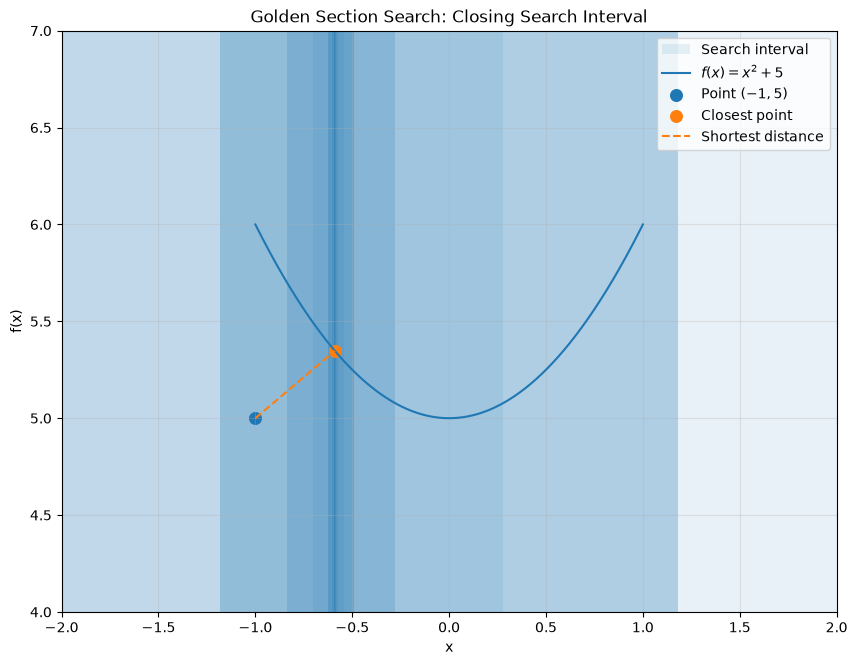

In [29]:
closest_y = f(closest_x)

x_values = np.linspace(-1, 1, 500)

plt.figure(figsize=(10, 8))

# Show the shrinking intervals
for i, (a, b) in enumerate(iterations):
    plt.axvspan(
        a, b,
        alpha=0.10,
        label="Search interval" if i == 0 else None
    )

# Plot parabola
plt.plot(x_values, f(x_values), label=r"$f(x)=x^2+5$")

# Original point
plt.scatter(x0, y0, s=70, label="Point $(-1,5)$")

# Closest point
plt.scatter(
    closest_x,
    closest_y,
    s=70,
    label="Closest point"
)

# Line showing shortest distance
plt.plot(
    [x0, closest_x],
    [y0, closest_y],
    "--",
    label="Shortest distance"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Golden Section Search: Closing Search Interval")

plt.xlim(-2, 2)
plt.ylim(4, 7)

plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    "media/golden.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()